# **Business Case: Netflix - Data Exploration and Visualisation**                                                                           


##**Submitted By: Aravinth Baskar**


# 1. Problem Statement

Netflix is one of the world's leading video streaming platforms, offering
thousands of movies and TV shows across multiple countries and languages. With increasing competition in the streaming industry, understanding audience preferences and content trends has become essential for making informed business decisions.

The objective of this project is to analyze Netflix's content library and identify meaningful patterns related to content type, genre, country, release trends, ratings, duration, actors, and directors. The insights obtained from this analysis will help understand Netflix's content strategy and provide recommendations for future content production and business expansion.




# 2. Business Objectives

The primary objectives of this analysis are:

- Understand the composition of Netflix's content library.
- Analyze content release and addition trends over time.
- Identify countries contributing the most content.
- Study popular genres across different regions.
- Identify the most frequently featured actors and directors.
- Analyze content ratings and duration patterns.
- Determine the best month to add TV Shows on Netflix based on historical content addition patterns.
- Analyze how Netflix's content strategy has evolved with respect to Movies and TV Shows.
- Generate actionable recommendations to support Netflix's future content production and global expansion.

# 3. Dataset Description

The dataset consists of movies and TV shows available on the Netflix platform. Each record represents a unique title and contains the following attributes:

- **show_id:** Unique identifier for each movie or TV show.
- **type:** Specifies whether the title is a Movie or a TV Show.
- **title:** Name of the movie or TV show.
- **director:** Director(s) of the title.
- **cast:** Main actors featured in the title.
- **country:** Country or countries where the title was produced.
- **date_added:** Date when the title was added to Netflix.
- **release_year:** Original release year of the title.
- **rating:** Content maturity rating assigned to the title.
- **duration:** Runtime (in minutes) for movies or the number of seasons for TV shows.
- **listed_in:** Genre(s) associated with the title.
- **description:** Brief summary of the movie or TV show.

# 4. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Load the Dataset

In [ ]:
!gdown 16BAdkcexEQTzkzYFAOVw0J_nd4itlWp9

Downloading...
From: https://drive.google.com/uc?id=16BAdkcexEQTzkzYFAOVw0J_nd4itlWp9
To: /content/netflix.csv
100% 3.40M/3.40M [00:00<00:00, 182MB/s]


In [ ]:
df = pd.read_csv("netflix.csv")

# 6. Data Understanding

## 6.1 Preview of the Dataset
Displaying the first 3 records gives a quick overview of the dataset's structure and attributes.

In [ ]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


## 6.2 Dataset Dimensions
The shape of the dataset indicates the total number of rows and columns available in the dataset.

In [ ]:
df.shape

(8807, 12)

## 6.3 Dataset Information
This section provides information about the column names, data types, non-null values, and memory usage of the dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 6.4 Statistical Summary
A statistical summary helps understand the distribution and characteristics of the dataset's attributes.

In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


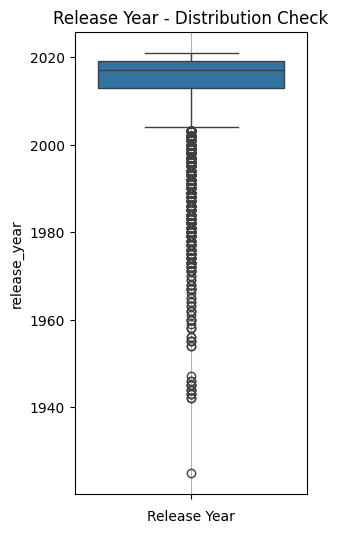

In [ ]:
plt.figure(figsize=(3,6))
sns.boxplot(data=df, y="release_year")
plt.title("Release Year - Distribution Check")
plt.xlabel("Release Year")
plt.grid(axis="x")
plt.show()

###Boxplot Inference
The boxplot confirms a handful of titles released well before the 1990s, appearing as individual points down of the main cluster. These are genuine older/classic titles rather than data errors so no removal or correction needed.

## 6.5 Missing Values
Identifying missing values helps determine the extent of incomplete data and the preprocessing required before analysis.

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## 6.6 Duplicate Records
Checking for duplicate records ensures the uniqueness and quality of the dataset.

In [ ]:
print(df.duplicated().sum())

0


##6.7 Observations

* The dataset contains 8,807 rows and 12 columns.
* The release_year column is numeric, whereas other columns are objects.
* The statistical summary provides descriptive statistics for the release_year column, indicating the range and distribution of it. Additionally box-plot is added for better visual.
* Missing values are present in the director, cast, country, date_added, rating, and duration columns.
* No duplicate rows were found in the dataset.


#7. Data Cleaning & Preprocessing

##7.1 Handling Missing Values

Before proceeding with the analysis, the missing values were examined to determine the appropriate treatment for each attribute. Rather than removing records, the percentage of missing values was analyzed to decide whether imputation or exclusion during specific analyses would be more appropriate.

In [ ]:
nulls = pd.DataFrame({"Missing Values": df.isna().sum(), "Percentage": round(df.isna().mean() * 100, 2)})
print(nulls.sort_values("Percentage", ascending = False))


              Missing Values  Percentage
director                2634       29.91
country                  831        9.44
cast                     825        9.37
date_added                10        0.11
rating                     4        0.05
duration                   3        0.03
show_id                    0        0.00
type                       0        0.00
title                      0        0.00
release_year               0        0.00
listed_in                  0        0.00
description                0        0.00


### Observation

The director column has the highest proportion of missing values followed by  country and cast.
Since missing values are concentrated in a few columns and deleting those rows would result in the loss of useful information, so the missing values will be retained.
Rows with missing values will be excluded only during analysis where the respective column is required.

## 7.2 Data Type Conversion

###7.2.1 Splitting Date to New Columns

The date_added column was converted to datetime format after removing leading and trailing whitespaces. Additional columns for the year and month of content added is created to facilitate time-based analysis.


In [ ]:
df["date_added"] = df["date_added"].str.strip()

In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"])

In [ ]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

###7.2.2 Categorical Datatype

The type and rating columns were converted to category dtype since each contains a small, fixed set of repeating values. Columns such as country, listed_in, director, and cast were left as strings, as they contain multiple comma-separated values per row and are only meaningfully categorical after being split and exploded, which is handled later in the relevant analysis sections.

In [ ]:
df["type"] = df["type"].astype("category")
df["rating"] = df["rating"].astype("category")

print(df[["type", "rating"]].dtypes)

type      category
rating    category
dtype: object


## 7.3 Handling Multi-Valued Columns

Some columns in the dataset such as country, director, cast, and listed_in contain multiple values separated by commas. These columns will be split and expanded into separate rows only when required for a specific analysis. This approach avoids creating unnecessarily large DataFrames and keeps the analysis focused on the relevant columns.

##7.4 Outlier Check

Since release_year was already summarized in section 6.4, the outlier check here focuses on duration for movies, using a boxplot to visually identify unusually short or long titles.


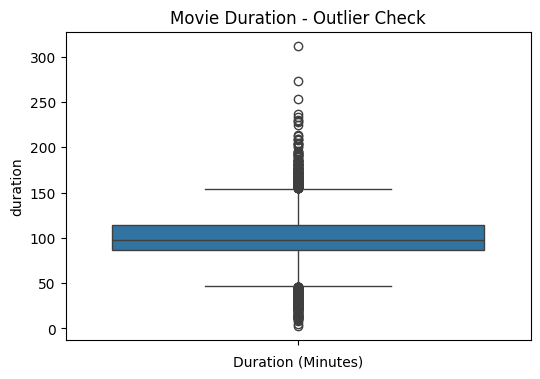

In [ ]:
outlier_check = df[df["type"] == "Movie"].copy()
outlier_check["duration"] = outlier_check["duration"].dropna().str.split().str[0].astype(int)
plt.figure(figsize=(6,4))
sns.boxplot(data=outlier_check, y="duration")
plt.title("Movie Duration - Outlier Check")
plt.xlabel("Duration (Minutes)")
plt.show()

### Observation

The boxplot shows few number of movies with unusually short or long durations, appearing as individual points beyond the main box. These are not treated as errors — very short titles are likely short films and very long titles are likely epics or special releases. No values were removed, since they represent genuine content rather than data entry mistakes.

# 8. Exploratory Data Analysis

This section explores the Netflix dataset to identify trends, patterns, and business insights. The analysis is divided into non-graphical, univariate and bivariate analyses to better understand the characteristics of the content library and Netflix's content strategy.

##8.1 Non-Graphical Analysis

Before visualizing the data, we examine the unique values and frequency distributions of key attributes. This provides a baseline understanding of the dataset's composition without relying on plots and highlights why several columns will need to be split and exploded before deeper analysis.

###8.1.1 Unique Value Counts


In [ ]:
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1714
release_year,74
rating,17
duration,220


### Observation
- show_id and title have as many unique values as there are rows, confirming each record represents a distinct title.
- director and cast show very high cardinality, reflecting the large number of individual contributors across the catalog.
- country, rating, and listed_in show comparatively low cardinality, but this count is still inflated by multi-value strings (e.g., "India, United States" counted separately from "United States, India")

###Business Insight
The wide range in cardinality across columns signals that some attributes (rating, type) can be analyzed directly, while others (director, cast, country, listed_in) require preprocessing before they can meaningfully inform content strategy decisions.

###8.1.2 Content Type — Raw Counts

In [ ]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


###Observation

Movies account for a clear majority of titles compared to TV Shows in raw count terms.

###Business Insight
The raw imbalance between Movies and TV Shows confirms that any genre, country, or actor/director analysis done without splitting by type would be dominated by movie-related patterns, reinforcing the need to segment by content type throughout the rest of the analysis.

###8.1.3 Rating — Raw Counts

In [ ]:
df["rating"].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


###Observation

- Mature-audience ratings (e.g., TV-MA, TV-14) appear more frequently than family-oriented ratings.
- The rating column mixes movie-style classifications (e.g., PG-13, R) with TV-style classifications (e.g., TV-MA, TV-14) within a single field.

###Business Insight
The skew toward mature ratings suggests Netflix's catalog is weighted toward adult and teen audiences rather than younger viewers.

###8.1.4 Cardinality Check on Multi-Value Columns (Raw, Unexploded)

In [ ]:
print("Unique raw country strings:", df["country"].nunique())
print("Unique raw genre strings:", df["listed_in"].nunique())
print("Unique raw director strings:", df["director"].nunique())
print("Unique raw cast strings:", df["cast"].nunique())

Unique raw country strings: 748
Unique raw genre strings: 514
Unique raw director strings: 4528
Unique raw cast strings: 7692


### Observation
The number of unique raw strings in country, listed_in, director, and cast is much higher than the number of individual countries, genres, directors, or actors actually represented — because entries like "India, United States" and "United States, India" are counted as different values.


### Business Insight
This confirms that country, listed_in, director, and cast cannot be analyzed in their raw form without significantly overstating the number of distinct categories. Splitting and exploding these columns, done in the bivariate analysis section, is necessary to get an accurate count of individual countries, genres, directors, and actors represented in the catalog.

## 8.2 Univariate Analysis

Univariate analysis examines one variable at a time to understand its distribution and key characteristics.

### 8.2.1 Distribution of Movies and TV Shows

This analysis compares the distribution of Movies and TV Shows available on Netflix to understand the overall composition of the content library.

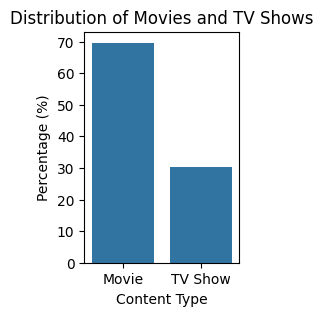

In [ ]:
perc = (df["type"].value_counts(normalize=True)*100).reset_index(name = "percentage")
plt.figure(figsize=(2,3))
sns.barplot(data = perc, x = "type", y = "percentage")
plt.xlabel("Content Type")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Movies and TV Shows")
plt.show()

### Observation

- Movies constitute approximately **69.6%** of the content available on Netflix, while TV Shows account for **30.4%**.
- This indicates that Netflix's content library is predominantly composed of movies.

### Business Insight

The higher proportion of movies suggests that Netflix has historically focused more on movie content than TV Shows. However, the presence of a substantial share of TV Shows indicates that both content types are important to the platform's overall content strategy.


### 8.2.2 Trends in Movie Releases Over the Last 30 Years

This analysis explores the trend in movie releases over the last 30 years to understand how movie production has evolved over time.

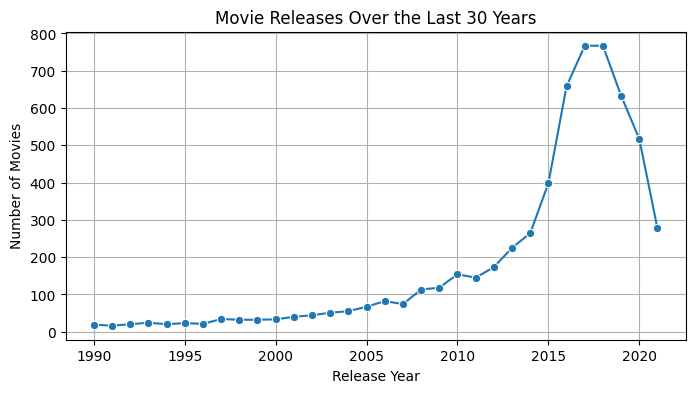

In [ ]:
movies_trend =(df[(df["type"] == "Movie") & (df["release_year"] >= 1990)]["release_year"]
               .value_counts().reset_index(name="count").sort_values("release_year"))
plt.figure(figsize=(8,4))
sns.lineplot(data = movies_trend, x = "release_year", y = "count", marker = "o")
plt.title("Movie Releases Over the Last 30 Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.xticks(range(1990, 2022, 5))
plt.grid()
plt.show()

### Observation
- The number of movies in the Netflix catalog released each year remained relatively low throughout the 1990s.
- Movie releases increased steadily from the early 2000s, with a sharp rise after 2015.
- The highest number of movie releases in the Netflix catalog was observed around 2017–2018.
- A decline in movie releases is noticeable after 2018.

### Business Insight

The concentration of movies released during 2017–2018 suggests that Netflix's catalog is heavily focused on relatively recent content. This indicates a preference for acquiring or producing newer movies, while the decline after 2018 reflect changes in content acquisition strategy or the composition of the current Netflix catalog.

### 8.2.3 Best Time of the Year to Add TV Shows

This analysis examines the monthly distribution of TV Shows added to Netflix to identify the period during which the platform most frequently introduces new TV content.

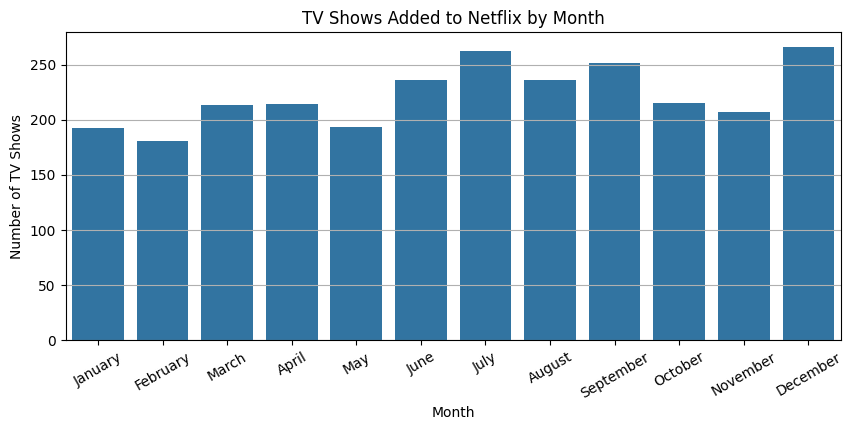

In [ ]:
tv_month = df[df["type"] == "TV Show"]["month_added"].value_counts().reset_index(name="count")
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
tv_month["month_added"] = pd.Categorical(tv_month["month_added"],categories=month_order,ordered=True)
tv_month = tv_month.sort_values("month_added")
plt.figure(figsize=(10,4))
sns.barplot(data=tv_month,x="month_added",y="count")
plt.title("TV Shows Added to Netflix by Month")
plt.xlabel("Month")
plt.ylabel("Number of TV Shows")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

### Observation

- TV Show additions are distributed throughout the year, with only moderate month-to-month variation.
- December recorded the highest number of TV Shows added to Netflix, closely followed by July and September.
- February had the lowest number of TV Show additions among all months.

### Business Insight

Netflix adds TV Shows throughout the year, indicating a consistent content strategy. The relatively higher additions during July, September, and December could be an attempt to attract more viewers during holiday and festive periods when audience engagement is typically higher.


### 8.2.4 Top Producing Countries

This analysis identifies the countries that have contributed the highest number of titles to Netflix, providing insights into the major content-producing regions on the platform.

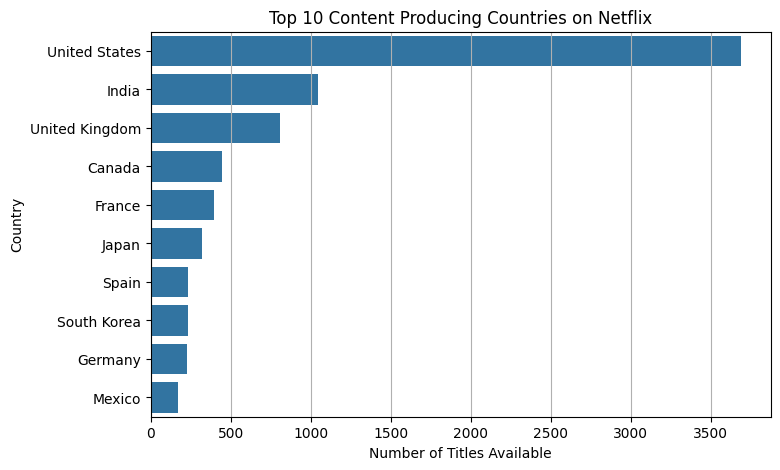

In [ ]:
countries = df.copy()
countries["country"] = countries["country"].str.split(",")
countries = countries.explode("country")
countries["country"] = countries["country"].str.strip()
top_countries= countries["country"].dropna().value_counts().head(10).reset_index(name = "count")
plt.figure(figsize=(8,5))
sns.barplot(data=top_countries, x="count", y="country")
plt.title("Top 10 Content Producing Countries on Netflix")
plt.xlabel("Number of Titles Available")
plt.ylabel("Country")
plt.grid(axis="x")
plt.show()

### Observation

- The United States contributes the highest number of titles to Netflix, far exceeding every other country.
- India ranks second, followed by the United Kingdom.
- The remaining countries contribute significantly fewer titles, indicating that Netflix's content library is concentrated among a few major producing countries.

### Business Insight

The dominance of the United States and India highlights Netflix's strong reliance on content from these major entertainment industries. At the same time, the presence of countries such as Japan, South Korea, Spain, and Germany reflects Netflix's growing investment in regional and international content to cater to a global audience.

### 8.2.5 Distribution of Movie Durations

This analysis examines the distribution of movie durations available on Netflix to understand the typical runtime and identify any unusual patterns.

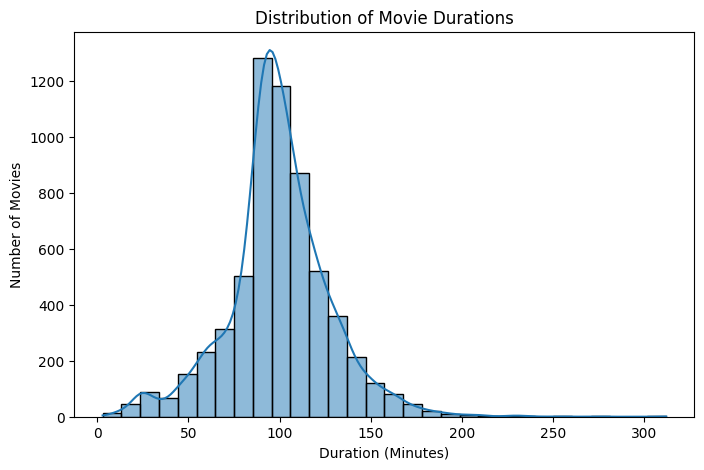

In [ ]:
movie_time = df.copy()
movie_time = movie_time[movie_time["type"] == "Movie"]
movie_time["duration"] = movie_time["duration"].dropna().str.split().str[0].astype(int)
movie_time = movie_time.loc[:,["title","duration"]]
plt.figure(figsize=(8,5))
sns.histplot(data = movie_time, x = "duration", bins = 30, kde = True)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

### Observation
- Most movies on Netflix have a runtime between 80 and 120 minutes, with the highest concentration around 90–100 minutes.
- The distribution is slightly right-skewed, indicating that while most movies have moderate runtimes, a smaller number of movies have significantly longer durations.
- Very short and very long movies are relatively uncommon in the Netflix catalog.

### Business Insight

The concentration of movies around the 90–100 minute mark suggests that Netflix's movie library primarily consists of standard feature-length films. This indicates a preference for runtimes that are likely to suit general audience viewing habits while still offering a smaller selection of longer movies for viewers seeking more extensive content.

## 8.3 Bivariate Analysis

Bivariate analysis examines the relationship between two variables to identify patterns, comparisons, and trends within the Netflix dataset. The following analyses compare different aspects of the content library to derive business insights and understand Netflix's content strategy.

### 8.3.1 Content Added to Netflix Over the Years by Content Type

This analysis compares the number of Movies and TV Shows added to Netflix over the years to understand how the platform's content acquisition strategy has evolved over time.

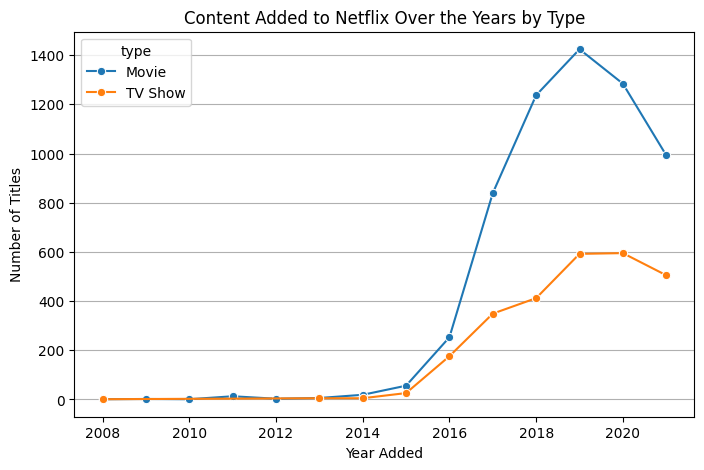

In [ ]:
content_trend = df.groupby(["year_added","type"],observed=True)["title"].count().reset_index(name="count")
trend_pivot = content_trend[content_trend["year_added"]>=2013].pivot(index="year_added", columns="type", values="count")
trend_pivot["tv_share_%"] = (trend_pivot["TV Show"] / (trend_pivot["Movie"] + trend_pivot["TV Show"]) * 100).round(1)
plt.figure(figsize=(8,5))
sns.lineplot(data = content_trend, x ="year_added", y = "count", hue = "type", marker = "o")
plt.title("Content Added to Netflix Over the Years by Type")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid(axis = "y")
plt.show()

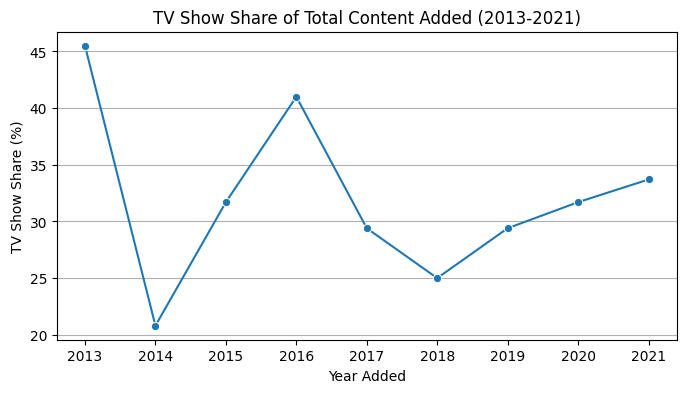

In [ ]:
plt.figure(figsize=(8,4))
sns.lineplot(data=trend_pivot.reset_index(), x="year_added", y="tv_share_%", marker="o")
plt.title("TV Show Share of Total Content Added (2013-2021)")
plt.xlabel("Year Added")
plt.ylabel("TV Show Share (%)")
plt.grid(axis="y")
plt.show()

### Observation

- The number of both Movies and TV Shows added to Netflix increased rapidly from 2016 onwards.
- Movies consistently outnumbered TV Shows throughout the observed period.
- Content additions peaked around 2019, after which both Movies and TV Shows experienced a gradual decline.
- TV Show's share of total content added shows a sharp initial drop from 2016 to 2018 (41.0% to 25.0%), followed by a steady year-over-year rise through 2021 (25.0% to 33.7%).
- The years 2013–2015 can be excluded from trend interpretation, since fewer than 100 total titles were added in each of those years, making the percentage highly sensitive to small changes in count.

### Business Insight

While Movies still account for the majority of titles added each year, the proportion dedicated to TV Shows has been rising consistently since 2018 — nearly 9 percentage points of share gained in three years (25.0% to 33.7%). This indicates a deliberate, ongoing shift in Netflix's content strategy toward TV Shows in recent years, even though the platform's overall catalog composition (69.6% Movies vs 30.4% TV Shows, per section 8.2.1) still favors Movies.

### 8.3.2 Top Directors by Content Type

This analysis identifies the directors with the highest number of Movies and TV Shows available on Netflix. Since a title can have multiple directors, the director column is split and exploded before analysis.

In [ ]:
directors_list = df.copy()
directors_list["director"] = directors_list["director"].dropna().str.split(",")
directors_list = directors_list.explode("director")
directors_list["director"] = directors_list["director"].str.strip()
directors_list = directors_list.groupby(["type", "director"],observed=True)["title"].count().reset_index(name="count")
top10_movie_dir = (directors_list[directors_list["type"] == "Movie"].sort_values("count", ascending=False)
.head(10).drop(columns="type"))
top10_tvshow_dir = (directors_list[directors_list["type"] == "TV Show"].sort_values("count", ascending=False)
.head(10).drop(columns="type"))
print("Top 10 Movie Directors")
print(top10_movie_dir)
print("-" * 35)
print("Top 10 TV Show Directors")
print(top10_tvshow_dir)

Top 10 Movie Directors
                 director  count
3582        Rajiv Chilaka     22
1817            Jan Suter     21
3633          Raúl Campos     19
4261          Suhas Kadav     16
2739         Marcus Raboy     15
1862            Jay Karas     15
727   Cathy Garcia-Molina     13
1859          Jay Chapman     12
2815      Martin Scorsese     12
4725      Youssef Chahine     12
-----------------------------------
Top 10 TV Show Directors
                   director  count
4923              Ken Burns      3
4785    Alastair Fothergill      3
4905          Joe Berlinger      2
5036            Stan Lathan      2
4877            Hsu Fu-chun      2
4861  Gautham Vasudev Menon      2
4945            Lynn Novick      2
5028            Shin Won-ho      2
5012        Rob Seidenglanz      2
4917             Jung-ah Im      2


### Observation

- The top Movie directors have contributed significantly more titles than the top TV Show directors on Netflix.
- Rajiv Chilaka is the most featured Movie director with 22 movies, followed by Jan Suter and Raúl Campos.
- In contrast, the highest number of TV Shows directed by a single director is only 3, indicating that TV Show direction is more evenly distributed.

### Business Insight

Netflix appears to rely more heavily on a few prolific directors for its Movie catalog, whereas its TV Show library is created by a much broader pool of directors. This diversity in TV Show direction may reflect the collaborative nature of television production and Netflix's strategy of partnering with a wider range of creators to produce varied and long-running series.

### 8.3.3 Top Actors by Content Type

This analysis identifies the actors who appear most frequently in Movies and TV Shows available on Netflix. Since a title can have multiple cast members, the cast column is split and exploded before analysis.

In [ ]:
cast_list = df.copy()
cast_list["cast"] = cast_list["cast"].dropna().str.split(",")
cast_list = cast_list.explode("cast")
cast_list["cast"] = cast_list["cast"].str.strip()
cast_list = cast_list.groupby(["type", "cast"],observed=True)["title"].count().reset_index(name="count")
top10_movie_cast = (cast_list[cast_list["type"] == "Movie"].sort_values("count", ascending=False)
.head(10).drop(columns="type"))
top10_tvshow_cast = (cast_list[cast_list["type"] == "TV Show"].sort_values("count", ascending=False)
.head(10).drop(columns="type"))
print("Top 10 Movie Actors")
print(top10_movie_cast)
print("-" * 40)
print("Top 10 TV Show Actors")
print(top10_tvshow_cast)

Top 10 Movie Actors
                   cast  count
2104        Anupam Kher     42
21781    Shah Rukh Khan     35
17193  Naseeruddin Shah     32
637        Akshay Kumar     30
18064           Om Puri     30
12031     Julie Tejwani     28
1312   Amitabh Bachchan     28
18329      Paresh Rawal     28
20692      Rupa Bhimani     27
3353        Boman Irani     27
----------------------------------------
Top 10 TV Show Actors
                     cast  count
39181    Takahiro Sakurai     25
40531           Yuki Kaji     19
26202           Ai Kayano     17
32755      Junichi Suwabe     17
28824         Daisuke Ono     17
40515     Yuichi Nakamura     16
32712        Jun Fukuyama     15
40447    Yoshimasa Hosoya     15
29077  David Attenborough     14
39196     Takehito Koyasu     13


### Observation

- The most frequently appearing actors differ significantly between Movies and TV Shows.
- Movie titles are dominated by Indian actors such as Anupam Kher, Shah Rukh Khan, Akshay Kumar, Amitabh Bachchan, and Paresh Rawal, reflecting Netflix's extensive collection of Indian cinema.
- In contrast, the TV Show category is largely represented by Japanese voice actors like Takahiro Sakurai, Yuki Kaji, and Ai Kayano indicating a strong presence of anime and animated series on the platform.

### Business Insight

The cast distribution highlights Netflix's regional content strategy. The Movie catalog has a strong focus on Indian films featuring well-known Bollywood actors, while the TV Show catalog is heavily influenced by Japanese anime, resulting in frequent appearances by renowned voice actors. This reflects Netflix's investment in region-specific content to cater to diverse global audiences.

### 8.3.4 Genre Distribution by Content Type

This analysis compares the most common genres among Movies and TV Shows to understand how Netflix's content portfolio differs across the two content types.

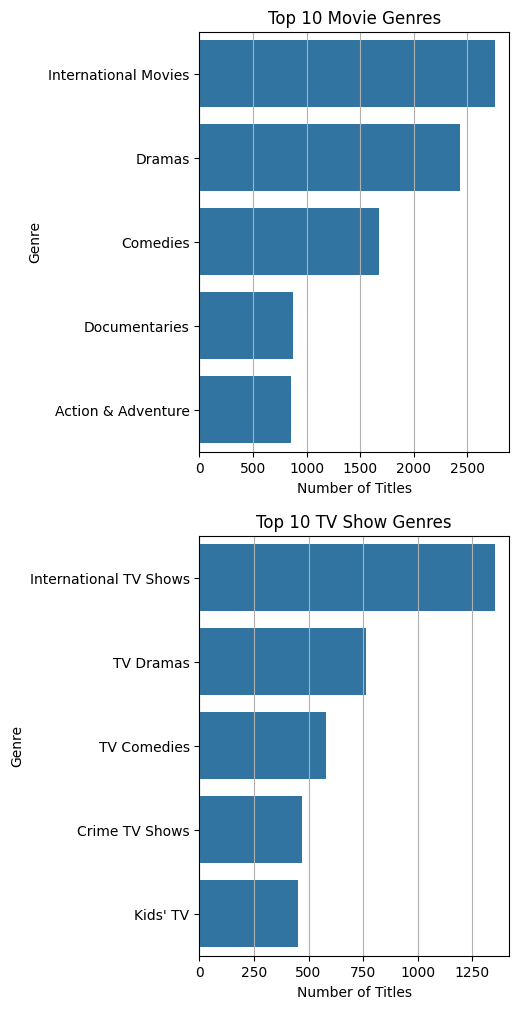

In [ ]:
genres = df.copy()
genres["listed_in"] = genres["listed_in"].dropna().str.split(",")
genres = genres.explode("listed_in")
genres["listed_in"] = genres["listed_in"].str.strip()
genres = genres.groupby(["type", "listed_in"],observed=True)["title"].count().reset_index(name="count")
top5_movie_genres = genres[genres["type"] == "Movie"].sort_values("count", ascending=False).head()
top5_tvshow_genres = genres[genres["type"] == "TV Show"].sort_values("count", ascending=False).head()
plt.figure(figsize=(4,12))
plt.subplot(2, 1, 1)
sns.barplot(data=top5_movie_genres,x="count",y="listed_in")
plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.grid(axis="x")
plt.subplot(2, 1, 2)
sns.barplot(data=top5_tvshow_genres,x="count",y="listed_in")
plt.title("Top 10 TV Show Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.grid(axis="x")
plt.show()


### Observation
- International Movies are the most common genre among Movies, while International TV Shows dominate the TV Show category.
- Dramas and Comedies are among the top genres for both Movies and TV Shows.
- Crime TV Shows and Kids TV also appear among the most popular TV Show genres.

### Business Insight
The dominance of international content shows that Netflix serves audiences across multiple countries instead of relying only on local productions. At the same time, maintaining a mix of drama, comedy, crime, and kids content helps the platform appeal to viewers with different interests.

### 8.3.5 Most Common Genre Among Top Producing Countries

This analysis identifies the most common genre for each of the top producing countries on Netflix. It helps understand the type of content each country contributes the most to the platform.

In [ ]:
top10_country = top_countries.head(10)["country"]
top_country_genre = countries.copy()
top_country_genre = top_country_genre[top_country_genre["country"].isin(top10_country)]
top_country_genre["listed_in"] = top_country_genre["listed_in"].dropna().str.split(",")
top_country_genre = top_country_genre.explode("listed_in")
top_country_genre["listed_in"] = top_country_genre["listed_in"].str.strip()
top_country_genre = top_country_genre.groupby(["country","listed_in"])["title"].count().reset_index(name="count")
best_genre = top_country_genre.sort_values(["country", "count"], ascending=[True, False]).groupby("country").head(1)
best_genre = best_genre.sort_values("count",ascending = False)
print(best_genre)


            country               listed_in  count
117           India    International Movies    864
315   United States                  Dramas    835
267  United Kingdom        British TV Shows    225
50           France    International Movies    207
215     South Korea  International TV Shows    152
154           Japan  International TV Shows    151
247           Spain    International Movies    140
5            Canada                Comedies     94
84          Germany    International Movies     94
186          Mexico    International Movies     70


### Observation

- International Movies are the most common genre for India, France, Spain, Germany, and Mexico.
- The United States contributes the highest number of Drama titles.
- The United Kingdom stands out with British TV Shows as its most common genre.
- Japan and South Korea primarily contribute International TV Shows, highlighting their strong presence in TV content.
- Canada stands out with Comedies as its most common genre.

### Business Insight

The results suggest that different countries have distinct content strengths on Netflix. While countries like India and France contribute mostly through International Movies, Japan and South Korea are more recognized for TV content. This indicates that Netflix benefits from sourcing different types of content from different regions.

### 8.3.6 Movie Duration Across Top 5 Content Ratings

This analysis compares the distribution of movie durations across the five most common content ratings on Netflix to understand whether movies targeting different audience groups tend to have different runtimes.

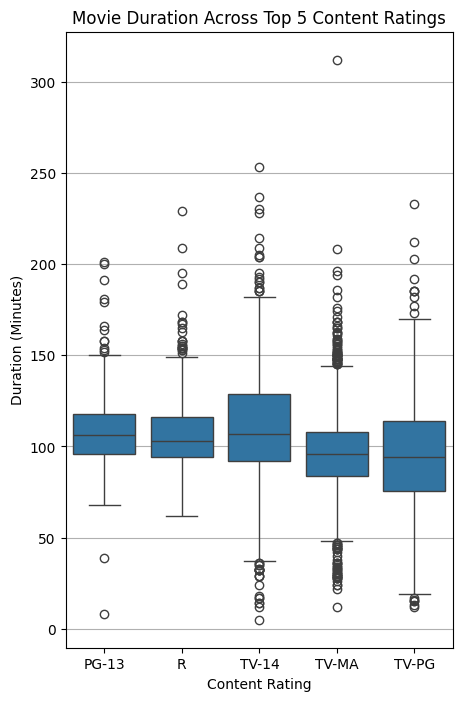

In [ ]:
top5_ratings = df.copy()
top5_ratings = top5_ratings[top5_ratings["type"]=="Movie"]
top5_ratings_final = top5_ratings["rating"].value_counts().head(5).reset_index()
top5_ratings_final = top5_ratings_final["rating"]
rating_duration = top5_ratings[top5_ratings["rating"].isin(top5_ratings_final)]
rating_duration = rating_duration.dropna(subset=["duration","rating"])
rating_duration["duration"] = rating_duration["duration"].str.split().str[0].astype(int)
rating_duration["rating"] = rating_duration["rating"].cat.remove_unused_categories()
plt.figure(figsize = (5,8))
sns.boxplot(data = rating_duration, x = "rating", y = "duration")
plt.title("Movie Duration Across Top 5 Content Ratings")
plt.xlabel("Content Rating")
plt.ylabel("Duration (Minutes)")
plt.grid(axis="y")
plt.show()

### Observation
- The median movie duration is fairly similar across all five content ratings, ranging between approximately 90 and 105 minutes.
- TV-14 movies show the widest spread in durations, indicating greater variation in movie lengths.
- PG-13 and R rated movies have relatively compact distributions, suggesting more consistent runtimes.
- All rating categories contain several long-duration outliers, with a few movies exceeding 200 minutes.

### Business Insight

Most movies on Netflix have a similar runtime regardless of their content rating. However, the presence of several long-duration outliers across all ratings suggests that Netflix does not impose a strict runtime based on audience classification and allows longer movies whenever the content demands it.

### 8.3.7 Time Gap Between Content Release and Addition to Netflix

This analysis measures the time difference between a title's release year and the year it was added to Netflix. Comparing Movies and TV Shows helps understand whether Netflix acquires different types of content at different stages of their lifecycle.

**Note:** 14 records had a negative time gap, where the year added preceded the release year. As this is logically impossible, these inconsistent records were excluded from the analysis.

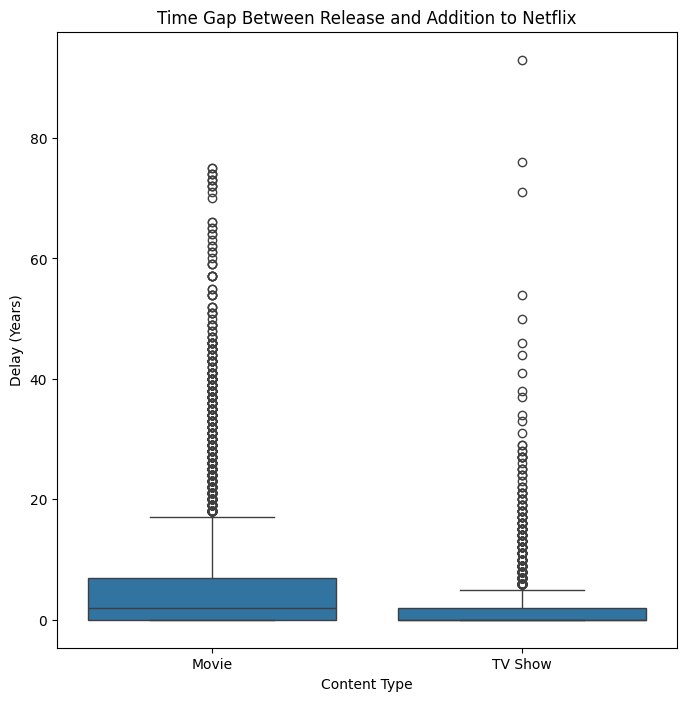

In [ ]:
time_gap = df.copy()
time_gap = time_gap.dropna(subset=["release_year","year_added"])
time_gap["delay"] = time_gap["year_added"]-time_gap["release_year"]
time_gap = time_gap[time_gap["delay"]>=0]
plt.figure(figsize=(8,8))
sns.boxplot(data = time_gap, x = "type", y = "delay")
plt.title("Time Gap Between Release and Addition to Netflix")
plt.xlabel("Content Type")
plt.ylabel("Delay (Years)")
plt.show()


### Observation

- TV Shows are generally added to Netflix sooner after their release compared to Movies.
- Movies have a higher median delay and a wider spread, indicating that they are acquired over a longer period after release.
- Both Movies and TV Shows contain several long-delay outliers, although such cases are more common for Movies.

### Business Insight

The shorter acquisition delay for TV Shows suggests that Netflix prioritizes adding recent series to keep its catalog fresh and relevant. In contrast, the wider acquisition window for Movies indicates that Netflix relies on a mix of newly released and older films to maintain a diverse movie library.

### 8.3.8 Trend of Top 5 Movie Genres Over the Years

This analysis explores the growth of Netflix's top five movie genres over the years based on the number of titles added to the platform. Understanding these trends helps identify the genres that have received the greatest investment and highlights how Netflix's movie catalog has evolved over time.

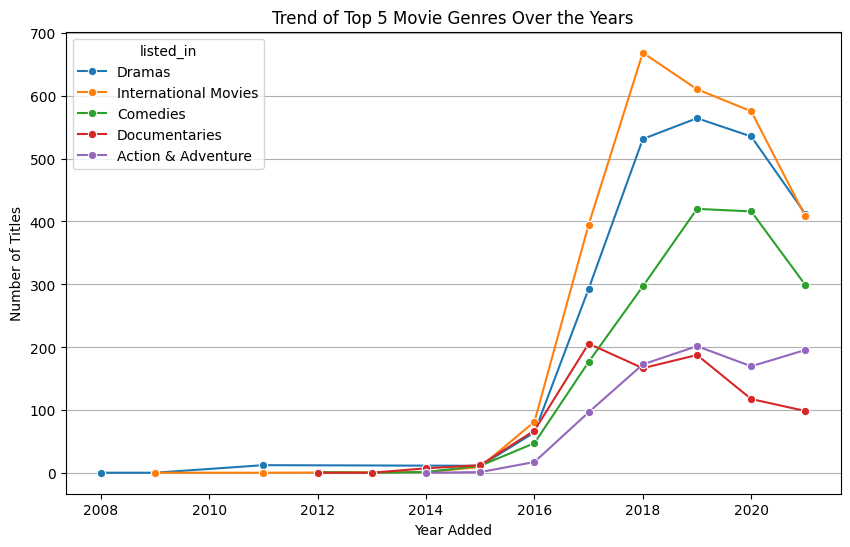

In [ ]:
top5_genres = top5_movie_genres["listed_in"].tolist()
genre_trend = df.copy()
genre_trend["listed_in"] = genre_trend["listed_in"].str.split(",")
genre_trend = genre_trend.explode("listed_in")
genre_trend["listed_in"] = genre_trend["listed_in"].str.strip()
genre_trend = genre_trend[genre_trend["listed_in"].isin(top5_genres)]
genre_trend = genre_trend.groupby(["year_added","listed_in"])["title"].count().reset_index(name="count")
plt.figure(figsize=(10,6))
sns.lineplot(data=genre_trend,x="year_added",y="count",hue="listed_in",marker="o")
plt.title("Trend of Top 5 Movie Genres Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid(axis="y")
plt.show()

### Observation

- All five genres witnessed rapid growth from 2016 onwards, reflecting Netflix's aggressive content expansion during this period.
- International Movies consistently remained the largest genre, peaking at around 670 titles in 2018.
- Dramas and Comedies followed a similar upward trend, with their highest additions occurring between 2018 and 2020.
- Documentaries experienced moderate growth but declined after 2019, while Action & Adventure continued to remain relatively stable.
- A decline across all genres is observed in 2021, indicating a slowdown in new content additions.

### Business Insight

Netflix expanded its catalog across multiple popular genres simultaneously rather than focusing on a single genre. However, International Movies and Dramas consistently received the highest number of additions, suggesting that these genres formed the core of Netflix's content acquisition strategy while maintaining a balanced portfolio across other genres.

# 9. Key Business Insights


## 9.1 Netflix's Growth Strategy is Driven by Global Content Expansion
Netflix's catalog expansion since 2016 was led by International Movies, which peaked at roughly 670 titles added in 2018 alone — more than any other genre in any single year. Combined with consistent investment in content from multiple countries (Section 8, Top Producing Countries), this points to a deliberate global-audience strategy rather than reliance on domestic (U.S.-only) productions.

## 9.2 Movies Still Dominate, But TV Shows Are Gaining Ground
Movies make up 69.6% of the overall catalog, but this overall figure masks a real shift underway: TV Show's share of new additions has risen from 25.0% in 2018 to 33.7% in 2021. Movies still dominate the historical catalog, but Netflix's more recent acquisition behavior shows a small growth trend toward TV Shows.

## 9.3 Movie Production Relies on a Concentrated Talent Pool, TV Shows Draw from a Broader One

Netflix relies on a small pool of highly prolific directors for Movies compared to TV Show directors. This asymmetry suggests Movie production follows a more repeatable, talent-concentrated formula, while TV Show production draws from a broader, more experimental creator base — a distinction relevant to how Netflix might scale each content type going forward.

## 9.4 Netflix Adds TV Shows Almost Immediately, Movies With More Delay
TV Shows are typically added to Netflix in the same year they're released — a median delay of 0 years — while Movies have a median delay of 2 years between release and addition. This suggests Netflix prioritizes acquiring TV Shows while they're still new and culturally relevant, while Movies are sourced from a mix of recent releases and older titles. The broader pattern that TV Show strategy is oriented around freshness and immediacy, whereas Movie strategy blends new and legacy content.


## 9.5 Runtime is Determined More by Storytelling than Audience Rating

Median movie duration stays within a narrow band of roughly 90–105 minutes across all five major content ratings, with no rating group showing a meaningfully shorter or longer typical runtime. This consistency suggests Netflix does not tailor runtime to audience classification — a handful of outlier titles exceeding 200 minutes exist across every rating group, showing that longer formats are used selectively based on the story rather than restricted to any one audience segment.

# 10. Business Recommendations

## 10.1 Continue Investing in International Content
International Movies peaked at roughly 670 titles added in a single year (2018) — the highest volume of any genre in any year in the dataset. Given this genre has consistently outpaced others in scale, Netflix should continue prioritizing partnerships with international production houses, particularly in markets like India, Japan, and South Korea that already show genre specialization, rather than spreading investment evenly across all regions.

##10.2 Accelerate Investment in TV Shows

TV Show's share of total content added has risen steadily from 25.0% in 2018 to 33.7% in 2021, even as Movies remain the larger overall share of the catalog. This upward trend, combined with TV Shows being added to Netflix almost immediately after release, suggests TV content is both a growing viewer preference and an operationally faster category to acquire. Netflix should treat TV Show investment as a priority growth lever rather than a secondary offering.

##10.3 Maintain a Balanced Genre Portfolio

While International Movies and Dramas lead in volume, genres such as Comedies, Documentaries, and Action & Adventure each maintained stable, meaningful contributions to the catalog rather than disappearing after the 2016–2019 expansion period. Netflix should continue maintaining this genre spread rather than over-concentrating investment in only the top one or two genres, since a diversified portfolio reduces dependency on any single content category's continued popularity.

##10.4 Prioritize Timely Acquisition, Especially for Movies

TV Shows already reach Netflix quickly after release, but Movies lag behind at a median of 2 years. To remain competitive with other streaming platforms that emphasize new releases, Netflix should work to narrow this Movie acquisition delay where possible, while continuing to selectively retain older titles that hold long-term catalog value.

##10.5 Strengthen Long-Term Partnerships with Proven Movie Directors, While Diversifying TV Talent

Movie production is concentrated around a small number of highly prolific directors. Netflix should continue deepening relationships with its most successful, repeat Movie directors to sustain output efficiently, while intentionally preserving the broader, more experimental creator base already present in TV Show production, since this diversity may be contributing to the category's rising share of new additions.

##10.6 Use Data-Driven Runtime Decisions
Movie runtimes remain consistent across audience ratings, with median durations clustering between 90 and 105 minutes regardless of certification. Netflix should continue treating runtime as a storytelling decision rather than a certification-driven one, reserving longer formats selectively for high-value projects — such as those involving established directors, popular franchises, or award-oriented content — rather than adjusting runtime expectations based on audience rating alone.

# 11. Conclusion

This project analyzed Netflix's content library to understand its composition, growth, and acquisition strategy, with the goal of informing future content production and business expansion decisions.

The data shows a clear split between Netflix's historical catalog and its recent trajectory. Movies still make up the majority of titles overall (69.6%), and the platform expanded aggressively across genres and countries between 2016 and 2019, led by International Movies and Dramas. But the most actionable pattern is a more recent one: TV Show's share of new additions has risen every year since 2018, from 25.0% to 33.7% by 2021, and TV Shows are consistently added to Netflix almost immediately after release, compared to a two-year median delay for Movies. Combined with a broader, less concentrated director base for TV production, this points to TV Shows as the stronger near-term growth lever, even though Movies remain the larger category today.

**Recommendation priority:**

If Netflix has to choose where to direct incremental investment first, the data most strongly supports accelerating TV Show production and acquisition, rather than further expanding an already-dominant Movie catalog.

